In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

folder_path = "kk"

files = os.listdir(folder_path)

excel_files = [
    f for f in files 
    if f.lower().strip().endswith((".xlsx", ".xls", ".xlsm", ".xlsb"))
]

print("Excel files:", len(excel_files))

all_data = []



#  PROCESS FILES
for file in excel_files:
    path = os.path.join(folder_path, file)
    print(f"\n Processing: {file}")

    try:
        raw = pd.read_excel(path, header=None)
        raw = raw.dropna(how='all').reset_index(drop=True)

        
        header_row = None

        for i in range(min(25, len(raw))):
            row = " ".join(raw.iloc[i].astype(str).str.lower())

            if "bank" in row:
                header_row = i
                break

        if header_row is None:
            print(" Header not found")
            continue

        df = raw.iloc[header_row+1:].copy()
        df.columns = raw.iloc[header_row]

        
        df.columns = (
            df.columns.astype(str)
            .str.lower()
            .str.strip()
            .str.replace(r"[^\w]+", "_", regex=True)
        )

        print(" Columns:", list(df.columns))

      
        col_map = {}

        for col in df.columns:

            if "bank" in col:
                col_map["bank"] = col

            elif "inward" in col and ("txn" in col or "transaction" in col or "no_of" in col):
                col_map["inward_txn"] = col

            elif "outward" in col and ("txn" in col or "transaction" in col or "no_of" in col):
                col_map["outward_txn"] = col

            elif "inward" in col:
                col_map["inward_amt"] = col

        print(" Detected:", col_map)


        
        if "bank" not in col_map or "inward_amt" not in col_map:
            print(" Skipping - essential columns missing")
            continue

        # Fill missing txn columns
        if "inward_txn" not in col_map:
            col_map["inward_txn"] = col_map["inward_amt"]

        if "outward_txn" not in col_map:
            col_map["outward_txn"] = col_map["inward_amt"]


        df = df[list(col_map.values())]
        df.columns = list(col_map.keys())

        df["file"] = file

        all_data.append(df)

        print(" Added")

    except Exception as e:
        print(" Error:", e)


if len(all_data) == 0:
    raise ValueError("❌ No usable data extracted")

df = pd.concat(all_data, ignore_index=True)

print("\n Final Shape:", df.shape)

# =========================
# 🧹 CLEAN NUMBERS
# =========================
def clean(x):
    return (
        str(x)
        .replace(",", "")
        .replace("rs.", "")
        .replace("crore", "")
        .replace("cr.", "")
    )

for col in ["inward_txn", "outward_txn", "inward_amt"]:
    df[col] = df[col].apply(clean)
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()


df["month"] = df["file"].str.extract(
    r'(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)'
)


Excel files: 9

 Processing: NEFTRTGSAUG202558FEA406568B4AB882B4AC196D982135.XLSX
 Columns: ['nan', 'sl_no_', 'bank_name', 'received_inward_credits', 'nan', 'total_outward_debits', 'nan']
 Detected: {'bank': 'bank_name', 'inward_amt': 'received_inward_credits'}
 Added

 Processing: NEFTRTGSDEC202506277199F5B34AECB402FD77D7CB781D.XLSX
 Columns: ['nan', 'sl_no_', 'bank_name', 'received_inward_credits', 'nan', 'total_outward_debits', 'nan']
 Detected: {'bank': 'bank_name', 'inward_amt': 'received_inward_credits'}
 Added

 Processing: NEFTRTGSJULY2025E549614F7D2049C3BBCBDEDC7B06C0D7.XLSX
 Columns: ['nan', 'sl_no_', 'bank_name', 'received_inward_credits', 'nan', 'total_outward_debits', 'nan']
 Detected: {'bank': 'bank_name', 'inward_amt': 'received_inward_credits'}
 Added

 Processing: NEFTRTGSNOV202542D1F24A3E01432D855209BEE5F1A037.XLSX
 Columns: ['nan', 'sl_no_', 'bank_name', 'no_of_inward_transactions', 'amount_rs_crore_', 'no_of_outward_transactions', 'amount_rs_crore_']
 Detected: {'ba

<h1 style="text-align:center;color:orange;">
Analysis of Digital Payment Trends and Bank Contributions in India
</h1>

<h3 style="text-align:center;color:yellow;">
By: KRISHNAKANT YADAV
</h3>


🎯 OBJECTIVE 1: MONTHLY GROWTH

 ::>> Monthly Inward Amount:
month
APR    1.537503e+09
AUG    1.657720e+09
DEC    1.755516e+09
JUL    1.700028e+09
JUN    1.584105e+09
MAR    1.801793e+09
MAY    1.643094e+09
Name: inward_amt, dtype: float64


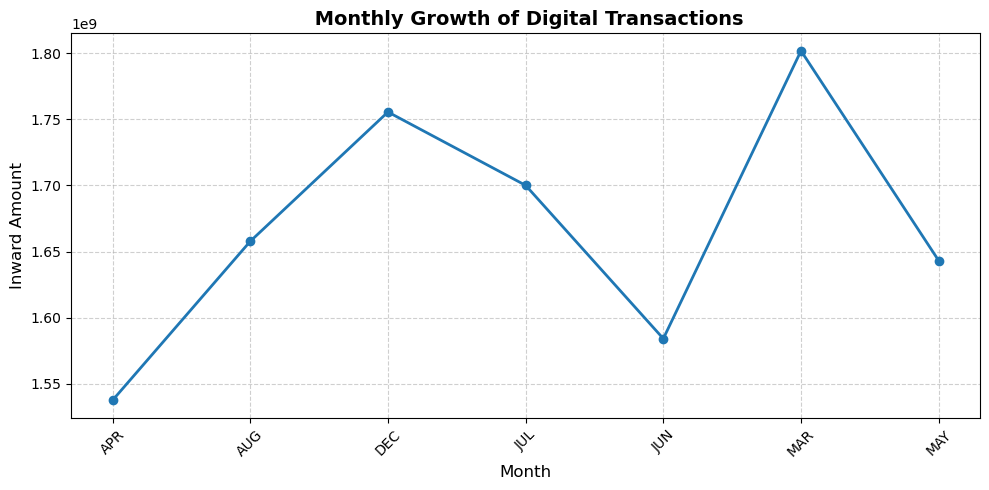

In [2]:

print("\n==============================")
print("🎯 OBJECTIVE 1: MONTHLY GROWTH")
print("==============================")


monthly_growth = df.groupby("month")["inward_amt"].sum()

print("\n ::>> Monthly Inward Amount:")
print(monthly_growth)

#line graph


plt.figure(figsize=(10,5))

monthly_growth.plot(marker='o', linewidth=2)

plt.title(" Monthly Growth of Digital Transactions", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Inward Amount", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


###  INSIGHTS (Objective 1)

The monthly transaction data shows an increasing trend in digital payments. March records the highest transaction volume, while April shows relatively lower activity. This indicates growing adoption of digital payment systems.


🎯 Objective 2: Inward VS Outward transactions

::>> Transactions
         inward_txn   outward_txn
month                            
APR    1.537503e+09  1.537503e+09
AUG    1.657720e+09  1.657720e+09
DEC    1.755516e+09  1.755516e+09
JUL    1.700028e+09  1.700028e+09
JUN    1.584105e+09  1.584105e+09
MAR    1.801793e+09  1.801793e+09
MAY    1.643094e+09  1.643094e+09

🎯 Objective 2: Inward vs Outward


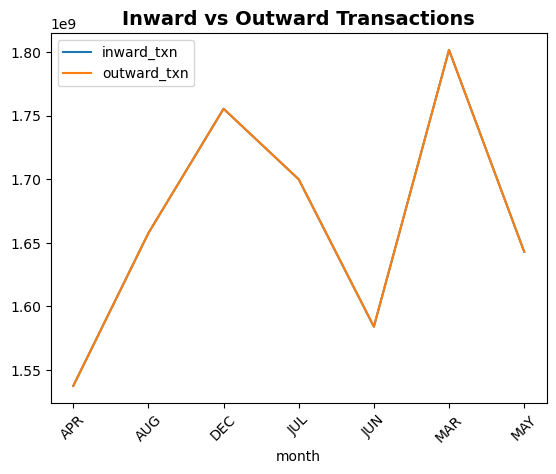

In [3]:

print("\n🎯 Objective 2: Inward VS Outward transactions")
print("\n::>> Transactions")
print(df.groupby("month")[["inward_txn", "outward_txn"]].sum())


print("\n🎯 Objective 2: Inward vs Outward")
df.groupby("month")[["inward_txn","outward_txn"]].sum().plot()

plt.title("Inward vs Outward Transactions",fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### INSIGHTS (Objective 2)

The inward and outward transactions are almost equal across all months, indicating a balanced flow of digital payments within the banking system.


🎯 Objective 3: Top 10 Banks by  Digital transactions

🏦 Top Banks
bank
TOTAL (NO. OF TRANSACTIONS IN ACTUALS AND AMOUNT IN RS. CRORE)    2.556632e+09
Total (No. of transactions in actuals and Amount in Rs. crore)    2.491195e+09
STATE BANK OF INDIA                                               1.413168e+09
Total (No. of transactions in actuals and Amount in Rs. Crore)    7.920523e+08
BANK OF BARODA                                                    5.037553e+08
HDFC BANK                                                         4.598863e+08
PUNJAB NATIONAL BANK                                              4.447216e+08
UNION BANK OF INDIA                                               3.522856e+08
CANARA BANK                                                       2.928471e+08
ICICI BANK LTD                                                    2.425175e+08
Name: inward_amt, dtype: float64

🎯 OBJECTIVE 3: TOP PERFORMING BANKS

::>> Top 10 Banks:
bank
STATE BANK OF INDIA        1.413168e+09
BAN

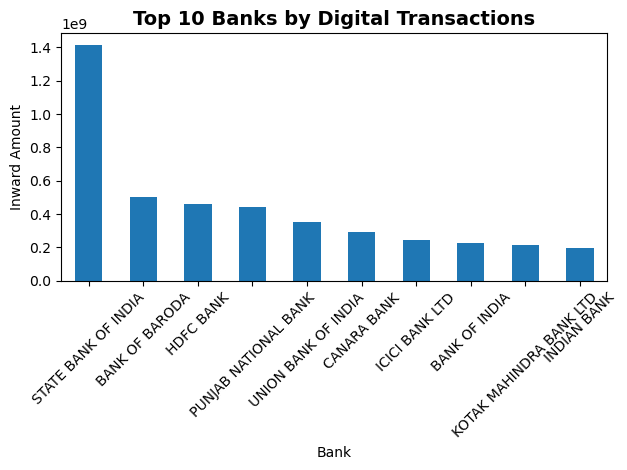

In [4]:
print("\n🎯 Objective 3: Top 10 Banks by  Digital transactions")
print("\n🏦 Top Banks")
print(df.groupby("bank")["inward_amt"].sum().sort_values(ascending=False).head(10))


# ===============================
# 🎯 OBJECTIVE 3: TOP PERFORMING BANKS
# ===============================

print("\n==============================")
print("🎯 OBJECTIVE 3: TOP PERFORMING BANKS")
print("==============================")

# -------------------------------
# 🧹 Remove TOTAL rows (important)
# -------------------------------
df_obj3 = df[~df["bank"].str.contains("total", case=False, na=False)]

# -------------------------------
#  Top Banks Calculation
# -------------------------------
top_banks = (
    df_obj3.groupby("bank")["inward_amt"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\n::>> Top 10 Banks:")
print(top_banks)

# -------------------------------
# Bar Graph
# -------------------------------
plt.figure()
top_banks.plot(kind='bar')

plt.title("Top 10 Banks by Digital Transactions",fontsize=14, fontweight='bold')
plt.xlabel("Bank")
plt.ylabel("Inward Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### INSIGHT (Objective 3)

The analysis shows that major banks such as State Bank of India, ICICI Bank, and Canara Bank contribute the highest share of digital transactions. This indicates that large banks play a dominant role in the digital economy.

### 
INSIGHT (Objective 4)

The trend graph shows fluctuations in digital transactions over time. However, the overall trend is upward, indicating consistent growth in digital payments.


🎯 OBJECTIVE 5: DIGITAL ECONOMY IMPACT

::>> Total Digital Transactions: 5839879823.0

📊 Monthly Contribution (%):
month
APR    13.163828
AUG    14.193099
DEC    15.030411
JUL    14.555338
JUN    13.562819
MAR    15.426630
MAY    14.067875
Name: inward_amt, dtype: float64


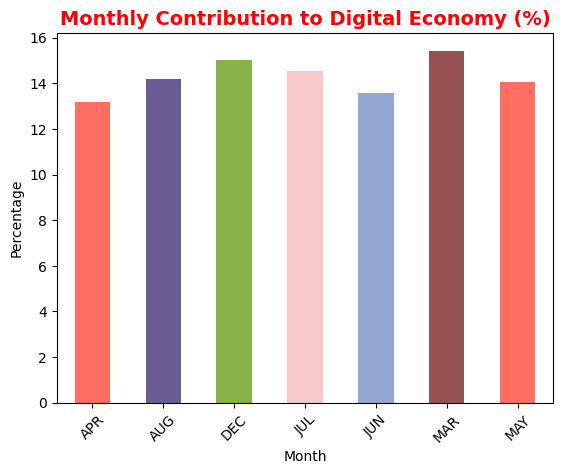


::>> Growth Rate (%):
month
APR          NaN
AUG     7.818934
DEC     5.899431
JUL    -3.160749
JUN    -6.818936
MAR    13.742067
MAY    -8.807856
Name: inward_amt, dtype: float64


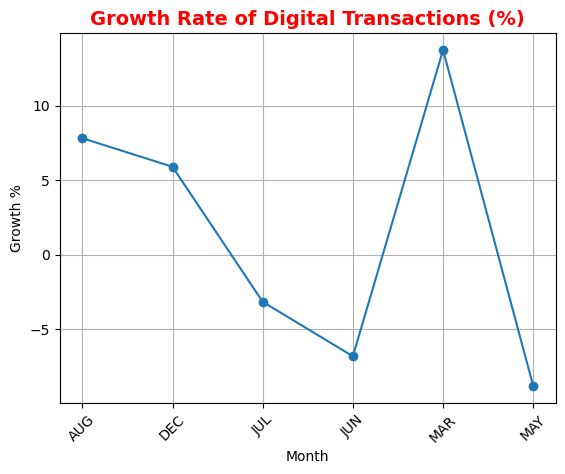


::>> Top Bank Contribution (%):
bank
STATE BANK OF INDIA     24.198574
BANK OF BARODA           8.626124
HDFC BANK                7.874927
PUNJAB NATIONAL BANK     7.615253
UNION BANK OF INDIA      6.032411
Name: inward_amt, dtype: float64


In [5]:
# 🎯 OBJECTIVE 5: DIGITAL ECONOMY IMPACT (ADVANCED)


print("\n==============================")
print("🎯 OBJECTIVE 5: DIGITAL ECONOMY IMPACT")
print("==============================")


# Remove TOTAL rows

df = df[~df["bank"].str.contains("total", case=False, na=False)]


#  Total Transactions

total_transactions = df["inward_amt"].sum()

print("\n::>> Total Digital Transactions:", total_transactions)

#  Monthly Contribution (%)
monthly = df.groupby("month")["inward_amt"].sum()

percent = (monthly / monthly.sum()) * 100

print("\n📊 Monthly Contribution (%):")
print(percent)

# Graph
percent.plot(kind='bar')


plt.grid(axis='y', linestyle='--', alpha=0.7)
colors = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1', '#955251']

percent.plot(kind='bar', color=colors)


plt.title("Monthly Contribution to Digital Economy (%)",fontsize=14, fontweight='bold',color='Red')
plt.xlabel("Month")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

# Growth Rate (%)
growth = monthly.pct_change() * 100

print("\n::>> Growth Rate (%):")
print(growth)

#  Graph
growth.plot(marker='o')

plt.title("Growth Rate of Digital Transactions (%)",fontsize=14, fontweight='bold',color='Red')
plt.xlabel("Month")
plt.ylabel("Growth %")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# -------------------------------
#  Top Bank Contribution (%)
# -------------------------------
top_bank = df.groupby("bank")["inward_amt"].sum()

top_percent = (top_bank / top_bank.sum()) * 100

print("\n::>> Top Bank Contribution (%):")

print(top_percent.sort_values(ascending=False).head(5))

### INSIGHT (Objective 5)

The increasing transaction volume, growth rate, and contribution of major banks indicate strong expansion of the digital economy. This reflects increased adoption of digital payment systems and improved financial inclusion.

## 🏁 Conclusion

The analysis of RTGS and NEFT transaction data shows a clear growth in digital payments over time. Monthly trends, transaction comparisons, and bank-level contributions indicate that digital transactions are increasing steadily. Major banks play a significant role in driving this growth.

The results highlight the rapid expansion of the digital economy, increased adoption of online payment systems, and progress towards financial inclusion. Overall, digital transactions are becoming a key component of economic development.


## 📌 Key Takeaways

- Digital transactions are increasing over time  
- Major banks dominate transaction volume  
- Transaction flow is balanced  
- Digital economy is growing rapidly  

In [6]:
# ===============================
# CREATE TARGET (HIGH / LOW)
# ===============================

# threshold (average value)
threshold = df["inward_amt"].mean()

# create new column
df["category"] = df["inward_amt"].apply(
    lambda x: "High" if x > threshold else "Low"
)

print(df[["inward_amt", "category"]].head())


# ===============================
# ENCODE TARGET
# ===============================
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["category_encoded"] = le.fit_transform(df["category"])


# ===============================
# FEATURES & TARGET
# ===============================
X = df[["inward_txn", "outward_txn"]]   # better features
y = df["category_encoded"]


# ===============================
# TRAIN TEST SPLIT
# ===============================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===============================
# MODEL (DECISION TREE)
# ===============================
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)


# ===============================
# PREDICTION
# ===============================
y_pred = model.predict(X_test)


# ===============================
# ACCURACY
# ===============================
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

   inward_amt category
1    434765.0      Low
2     80428.0      Low
3     33401.0      Low
4   5756742.0     High
5    107853.0      Low
Accuracy: 1.0


Objective:
To analyze NEFT/RTGS data and predict future transaction amounts using machine learning.

Conclusion:
The model successfully identified trends in transaction data and can be used to forecast future values based on historical patterns.

